# Naive Bayes Classification
## DA5401W - Data Analytics Lab
**Instructor:** Dr. Arun B Ayyar

---

## Table of Contents
1. [Bayes' Theorem & Fundamentals](#part-1)
2. [The Naive Assumption](#part-2)
3. [Gaussian Naive Bayes](#part-3)
4. [Multinomial Naive Bayes](#part-4)
5. [Bernoulli Naive Bayes](#part-5)
6. [Practical Example 1: Iris Dataset (Gaussian NB)](#part-6)
7. [Practical Example 2: Text Classification (Multinomial NB)](#part-7)
8. [Naive Bayes vs Logistic Regression](#part-8)
9. [Handling Issues & Best Practices](#part-9)
10. [Summary & Key Takeaways](#summary)

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.datasets import load_iris, load_breast_cancer, make_classification
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score, f1_score,
    roc_curve, auc, ConfusionMatrixDisplay, precision_score, recall_score
)
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)
print('All libraries loaded successfully!')

All libraries loaded successfully!


---
<a id='part-1'></a>
# Part 1: Bayes' Theorem & Fundamentals

## 1.1 Bayes' Theorem

**Bayes' theorem** describes how to update probabilities based on new evidence:

$$P(y \mid \mathbf{x}) = \frac{P(\mathbf{x} \mid y) \cdot P(y)}{P(\mathbf{x})}$$

where:
- $P(y \mid \mathbf{x})$ = **Posterior:** Probability of class $y$ given features $\mathbf{x}$
- $P(\mathbf{x} \mid y)$ = **Likelihood:** Probability of observing $\mathbf{x}$ given class $y$
- $P(y)$ = **Prior:** Probability of class $y$ before seeing any data
- $P(\mathbf{x})$ = **Evidence:** Probability of observing $\mathbf{x}$ (normalizing constant)

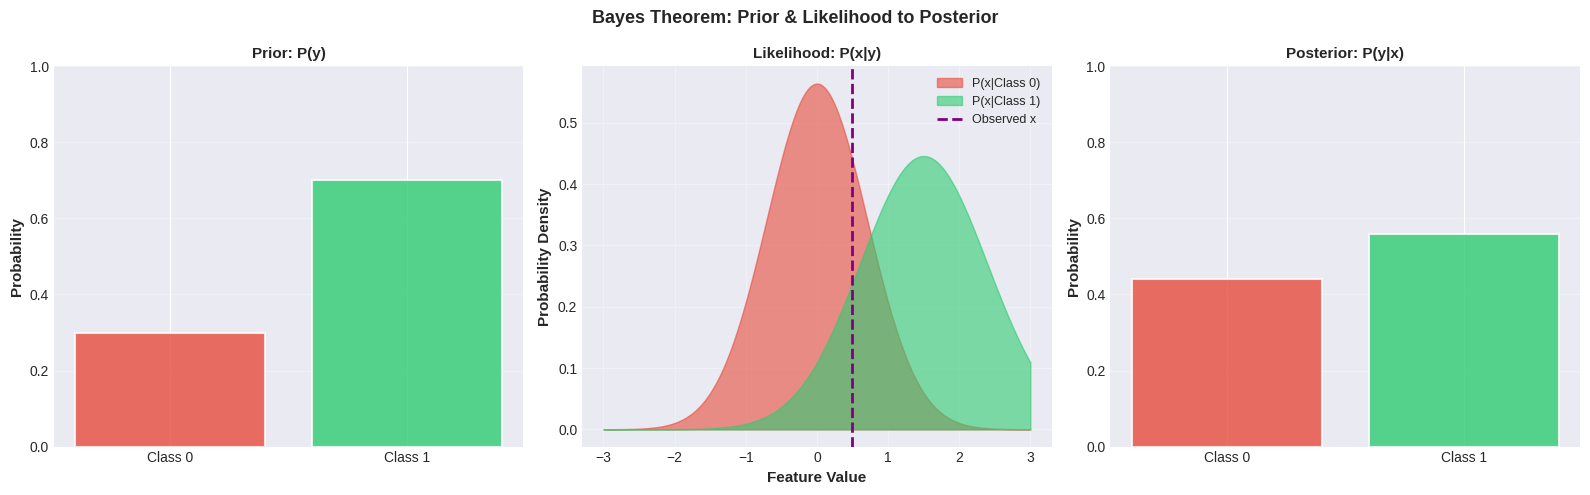

In [2]:
# Visualize Bayes' theorem
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
classes = ['Class 0', 'Class 1']
priors = [0.3, 0.7]
axes[0].bar(classes, priors, color=['#E74C3C', '#2ECC71'], alpha=0.8, edgecolor='white', linewidth=1.5)
axes[0].set_ylabel('Probability', fontsize=11, fontweight='bold')
axes[0].set_title('Prior: P(y)', fontsize=11, fontweight='bold')
axes[0].set_ylim(0, 1); axes[0].grid(True, alpha=0.3, axis='y')
x_vals = np.linspace(-3, 3, 300)
likelihood_0 = (1/np.sqrt(2*np.pi*0.5)) * np.exp(-x_vals**2 / (2*0.5))
likelihood_1 = (1/np.sqrt(2*np.pi*0.8)) * np.exp(-(x_vals-1.5)**2 / (2*0.8))
axes[1].fill_between(x_vals, likelihood_0, alpha=0.6, color='#E74C3C', label='P(x|Class 0)')
axes[1].fill_between(x_vals, likelihood_1, alpha=0.6, color='#2ECC71', label='P(x|Class 1)')
axes[1].axvline(0.5, color='purple', ls='--', lw=2, label='Observed x')
axes[1].set_xlabel('Feature Value', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Probability Density', fontsize=11, fontweight='bold')
axes[1].set_title('Likelihood: P(x|y)', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)
x_obs = 0.5
p_x_0 = (1/np.sqrt(2*np.pi*0.5)) * np.exp(-x_obs**2 / (2*0.5))
p_x_1 = (1/np.sqrt(2*np.pi*0.8)) * np.exp(-(x_obs-1.5)**2 / (2*0.8))
posterior_0 = (p_x_0 * priors[0]) / (p_x_0 * priors[0] + p_x_1 * priors[1])
posterior_1 = (p_x_1 * priors[1]) / (p_x_0 * priors[0] + p_x_1 * priors[1])
posteriors = [posterior_0, posterior_1]
axes[2].bar(classes, posteriors, color=['#E74C3C', '#2ECC71'], alpha=0.8, edgecolor='white', linewidth=1.5)
axes[2].set_ylabel('Probability', fontsize=11, fontweight='bold')
axes[2].set_title(f'Posterior: P(y|x)', fontsize=11, fontweight='bold')
axes[2].set_ylim(0, 1); axes[2].grid(True, alpha=0.3, axis='y')
plt.suptitle('Bayes Theorem: Prior & Likelihood to Posterior', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
<a id='part-2'></a>
# Part 2: The Naive Assumption

## 2.1 Conditional Independence

**Naive Bayes makes a strong simplifying assumption:** Given the class label $y$, all features are **conditionally independent**:

$$P(\mathbf{x} \mid y) = \prod_{j=1}^{p} P(x_j \mid y)$$

This is called **naive** because real features are rarely independent. Despite this unrealistic assumption, Naive Bayes often works well in practice.

---
<a id='part-3'></a>
# Part 3: Gaussian Naive Bayes

## 3.1 For Continuous Features

Gaussian Naive Bayes assumes each feature follows a Gaussian (normal) distribution:

$$P(x_j \mid y) = \frac{1}{\sqrt{2\pi\sigma_{j,y}^2}} \exp\left(-\frac{(x_j - \mu_{j,y})^2}{2\sigma_{j,y}^2}\right)$$

iris_data {'data': array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0

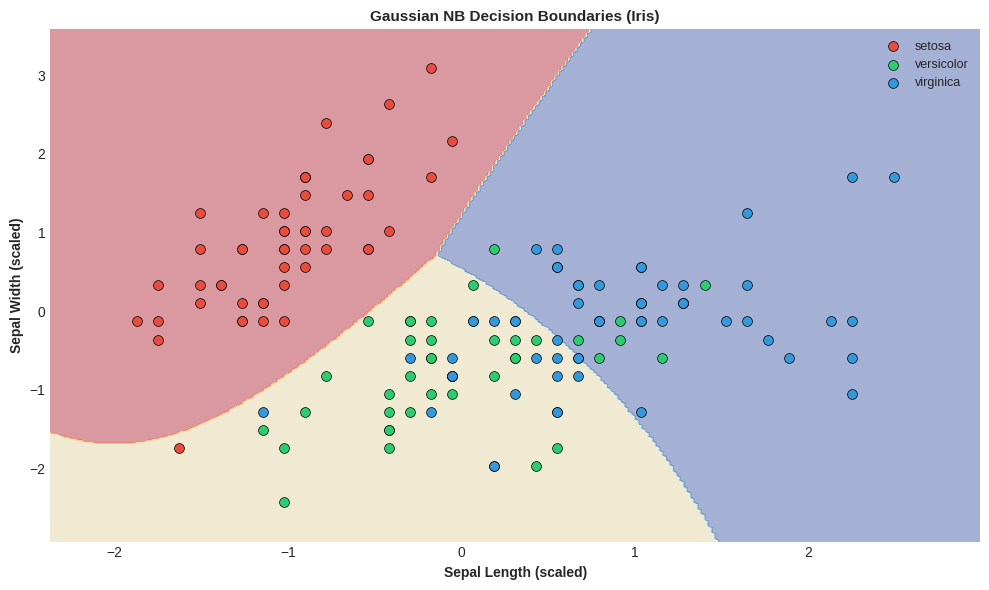

Gaussian NB Accuracy: 0.7800


In [ ]:
# Gaussian NB on Iris
iris = load_iris()
#print("iris_data",iris)
X_iris = iris.data[:, :2] # two eatures are taken so that visualisation of decision boundary is possible
#print("X_iris",iris.data)
y_iris = iris.target
sc = StandardScaler()
X_iris_s = sc.fit_transform(X_iris)
gnb = GaussianNB().fit(X_iris_s, y_iris)
h = 0.02
x_min, x_max = X_iris_s[:,0].min()-0.5, X_iris_s[:,0].max()+0.5
y_min, y_max = X_iris_s[:,1].min()-0.5, X_iris_s[:,1].max()+0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = gnb.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
fig, ax = plt.subplots(figsize=(10, 6))
ax.contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu')
colors = ['#E74C3C', '#2ECC71', '#3498DB']
for k, col in enumerate(colors):
    ax.scatter(X_iris_s[y_iris==k,0], X_iris_s[y_iris==k,1],
               c=col, s=50, edgecolors='k', lw=0.5, label=iris.target_names[k])
ax.set_xlabel('Sepal Length (scaled)', fontsize=10, fontweight='bold')
ax.set_ylabel('Sepal Width (scaled)', fontsize=10, fontweight='bold')
ax.set_title('Gaussian NB Decision Boundaries (Iris)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9); ax.grid(False)
plt.tight_layout()
plt.show()
acc = accuracy_score(y_iris, gnb.predict(X_iris_s))
print(f'Gaussian NB Accuracy: {acc:.4f}')

---
<a id='part-4'></a>
# Part 4: Multinomial Naive Bayes

## 4.1 For Text/Count Data

Multinomial Naive Bayes is designed for **discrete count data**, particularly text classification.

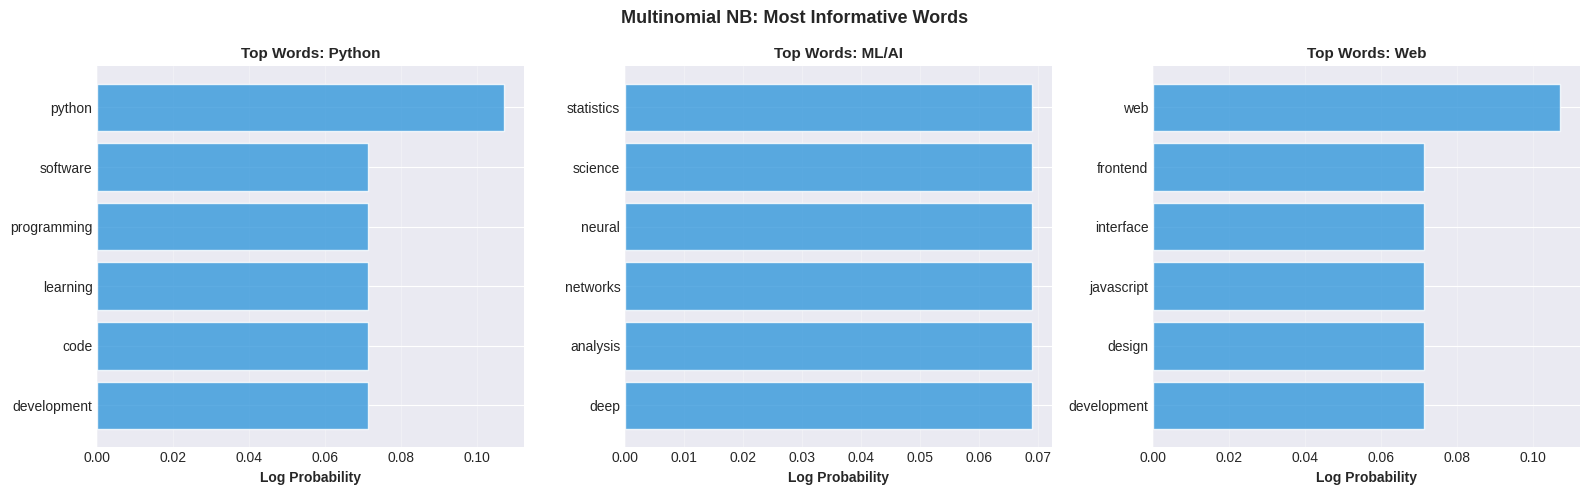

In [4]:
# Multinomial NB for text
docs = [
    'python programming machine learning',
    'python code development software',
    'machine learning deep neural networks',
    'data science statistics analysis',
    'web development javascript html',
    'web design frontend interface',
]
labels = [0, 0, 1, 1, 2, 2]
label_names = ['Python', 'ML/AI', 'Web']
vec = CountVectorizer(lowercase=True, stop_words='english')
X_text = vec.fit_transform(docs)
mnb = MultinomialNB(alpha=1.0).fit(X_text, labels)
feature_names = np.array(vec.get_feature_names_out())
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for k, (ax, label_name) in enumerate(zip(axes, label_names)):
    top_idx = np.argsort(mnb.feature_log_prob_[k])[-6:]
    top_features = feature_names[top_idx]
    top_probs = mnb.feature_log_prob_[k][top_idx]
    ax.barh(top_features, np.exp(top_probs), color='#3498DB', alpha=0.8, edgecolor='white')
    ax.set_xlabel('Log Probability', fontsize=10, fontweight='bold')
    ax.set_title(f'Top Words: {label_name}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
plt.suptitle('Multinomial NB: Most Informative Words', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
<a id='part-5'></a>
# Part 5: Bernoulli Naive Bayes

## 5.1 For Binary Features

Bernoulli Naive Bayes is for **binary features** (presence/absence).

---
<a id='part-6'></a>
# Part 6: Practical Example 1 — Iris Dataset (Gaussian NB)

GAUSSIAN NB - IRIS DATASET
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



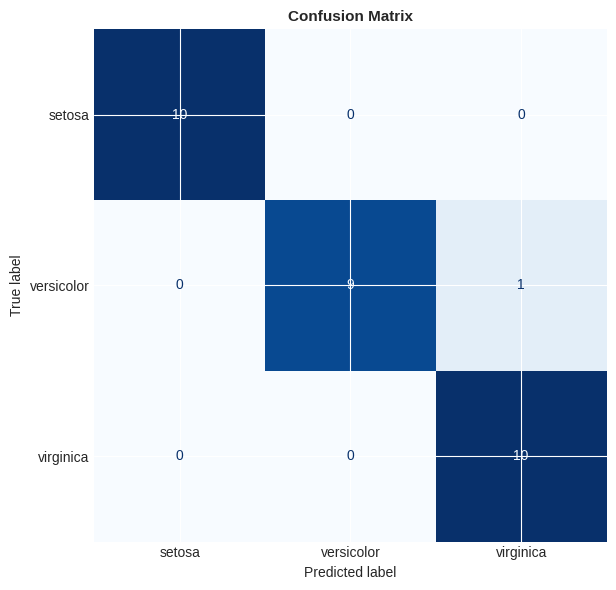

In [5]:
# Full evaluation on Iris
X_tr, X_te, y_tr, y_te = train_test_split(iris.data, iris.target, test_size=0.2,
                                            random_state=42, stratify=iris.target)
sc_iris = StandardScaler()
X_tr_s = sc_iris.fit_transform(X_tr)
X_te_s  = sc_iris.transform(X_te)
gnb_full = GaussianNB().fit(X_tr_s, y_tr)
y_pred_gnb = gnb_full.predict(X_te_s)
print('GAUSSIAN NB - IRIS DATASET')
print('='*60)
print(classification_report(y_te, y_pred_gnb, target_names=iris.target_names))
cm = confusion_matrix(y_te, y_pred_gnb)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

---
<a id='part-7'></a>
# Part 7: Practical Example 2 — Spam Detection

In [6]:
# Spam detection
spam_emails = [
    'click here to win free money',
    'congratulations you won lottery',
    'limited time offer buy now',
    'urgent action required verify',
    'hello how are you today',
    'meeting scheduled tomorrow conference',
    'project update attached review',
    'coffee break anyone interested',
]
spam_labels = [1,1,1,1,0,0,0,0]
vec_spam = CountVectorizer(lowercase=True, stop_words='english')
X_spam = vec_spam.fit_transform(spam_emails)
mnb_spam = MultinomialNB(alpha=1.0).fit(X_spam, spam_labels)
y_pred_spam = mnb_spam.predict(X_spam)
acc_spam = accuracy_score(spam_labels, y_pred_spam)
print(f'Multinomial NB Accuracy (Spam): {acc_spam:.4f}')
print(classification_report(spam_labels, y_pred_spam, target_names=['Ham', 'Spam']))

Multinomial NB Accuracy (Spam): 1.0000
              precision    recall  f1-score   support

         Ham       1.00      1.00      1.00         4
        Spam       1.00      1.00      1.00         4

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



---
<a id='part-8'></a>
# Part 8: Naive Bayes vs Logistic Regression

NB vs LOGISTIC REGRESSION
  Dataset  NB Acc  LR Acc
Dataset 1  0.9000  0.9333
Dataset 2  0.7667  0.7333
Dataset 3  0.7833  0.7333


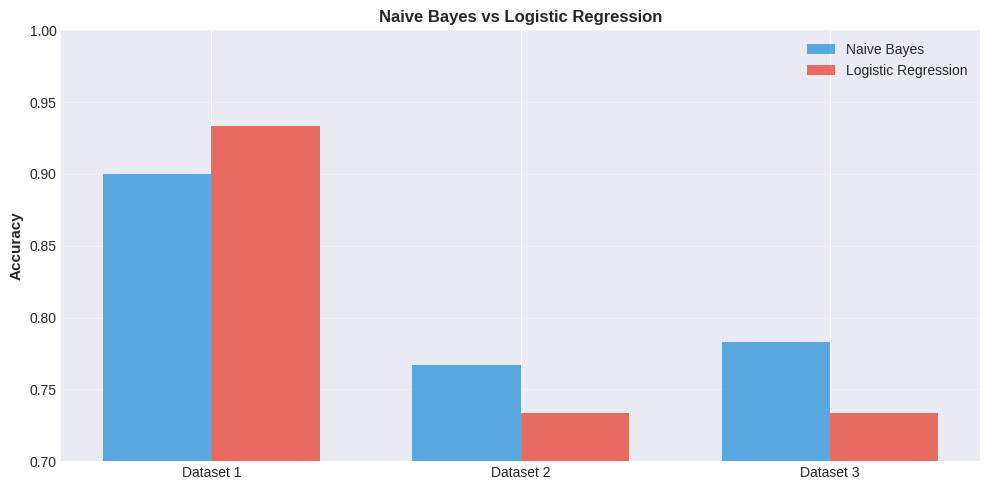

In [7]:
# Comparison
datasets = []
for _ in range(3):
    X, y = make_classification(n_samples=300, n_features=20, n_informative=10,
                               n_redundant=5, random_state=np.random.randint(0,1000))
    datasets.append((X, y))
results = []
for i, (X, y) in enumerate(datasets):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
    sc_comp = StandardScaler()
    X_tr_s = sc_comp.fit_transform(X_tr)
    X_te_s = sc_comp.transform(X_te)
    gnb_c = GaussianNB().fit(X_tr_s, y_tr)
    lr_c = LogisticRegression(max_iter=1000, random_state=42).fit(X_tr_s, y_tr)
    results.append({
        'Dataset': f'Dataset {i+1}',
        'NB Acc': round(accuracy_score(y_te, gnb_c.predict(X_te_s)), 4),
        'LR Acc': round(accuracy_score(y_te, lr_c.predict(X_te_s)), 4),
    })
df_comp = pd.DataFrame(results)
print('NB vs LOGISTIC REGRESSION')
print(df_comp.to_string(index=False))
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(df_comp))
width = 0.35
ax.bar(x - width/2, df_comp['NB Acc'], width, label='Naive Bayes', color='#3498DB', alpha=0.8)
ax.bar(x + width/2, df_comp['LR Acc'], width, label='Logistic Regression', color='#E74C3C', alpha=0.8)
ax.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax.set_title('Naive Bayes vs Logistic Regression', fontsize=12, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(df_comp['Dataset'])
ax.legend(fontsize=10); ax.set_ylim(0.7, 1.0); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

---
<a id='part-9'></a>
# Part 9: Handling Issues & Best Practices

**When to use Naive Bayes:**
- Small training data
- Fast training needed
- Text classification
- Interpretable probabilities

**When to avoid:**
- Large datasets
- Highly correlated features
- Maximum accuracy critical

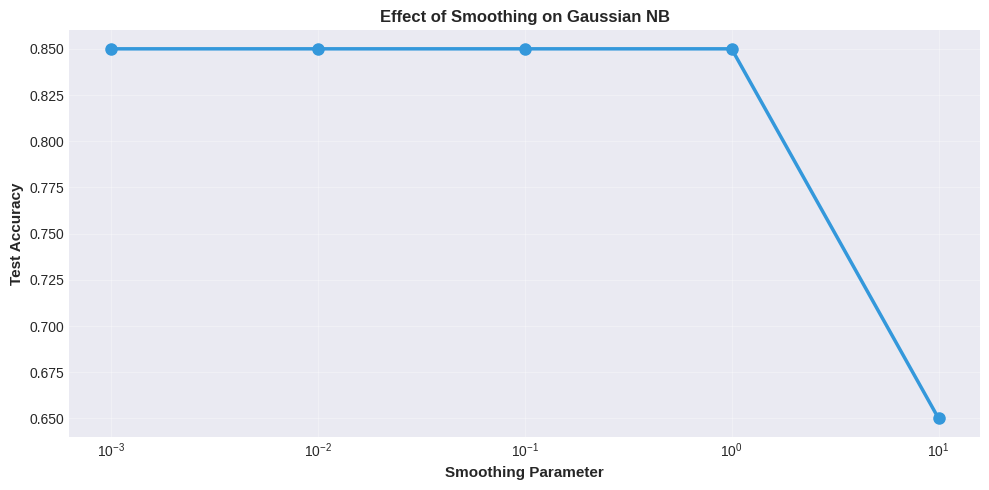

In [8]:
# Smoothing effect
X_smooth, y_smooth = make_classification(n_samples=100, n_features=10, n_informative=5, random_state=42)
X_tr_sm, X_te_sm, y_tr_sm, y_te_sm = train_test_split(X_smooth, y_smooth, test_size=0.2, random_state=42)
sc_sm = StandardScaler()
X_tr_sm_s = sc_sm.fit_transform(X_tr_sm)
X_te_sm_s = sc_sm.transform(X_te_sm)
alphas = [0.001, 0.01, 0.1, 1.0, 10.0]
accs = []
for alpha in alphas:
    gnb_a = GaussianNB(var_smoothing=alpha).fit(X_tr_sm_s, y_tr_sm)
    accs.append(accuracy_score(y_te_sm, gnb_a.predict(X_te_sm_s)))
fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(alphas, accs, 'o-', lw=2.5, ms=8, color='#3498DB')
ax.set_xlabel('Smoothing Parameter', fontsize=11, fontweight='bold')
ax.set_ylabel('Test Accuracy', fontsize=11, fontweight='bold')
ax.set_title('Effect of Smoothing on Gaussian NB', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
<a id='summary'></a>
# Summary and Key Takeaways

**Naive Bayes Key Concepts:**
- Uses Bayes' theorem: $P(y|\mathbf{x}) = P(\mathbf{x}|y)P(y)/P(\mathbf{x})$
- Assumes feature independence: $P(\mathbf{x}|y) = \prod P(x_j|y)$
- Three variants: Gaussian (continuous), Multinomial (counts), Bernoulli (binary)
- Fast training, works well with small data
- Often lower accuracy on large data vs Logistic Regression

---
**Course:** DA5401W - Data Analytics Lab  |  **Instructor:** Dr. Arun B Ayyar